In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-
"""
Repair Profit Analysis
  (1) Profit pre- vs post-repair for all datasets
  (2) Repair-only baseline: zero schedule → repair → profit
"""

import os, csv, math, glob
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict

# ============================================================================
# Config — point to your new_outputs folder
# ============================================================================
BASE_DIR = "/content/drive/MyDrive/energy_finetuning_35/new_outputs"

# Original → Corrected file pairs  (add/remove as needed)
FILE_PAIRS = [
    ("gpt4_hourly_arbitrage_new_york_2023.csv",
     "gpt4_hourly_arbitrage_new_york_2023_corrected.csv"),
    ("gpt4_hourly_arbitrage_new_york_2022_corrected.csv",
     "gpt4_hourly_arbitrage_new_york_2022_corrected_1.csv" # this was the merged original
     ),  # set to None if no separate corrected file
    ("gpt4_hourly_arbitrage_texas_2022.csv",
     "gpt4_hourly_arbitrage_texas_2022_corrected.csv"),
    ("gpt4_hourly_arbitrage_texas_2023.csv",
     "gpt4_hourly_arbitrage_texas_2023_corrected.csv"),
]

# Auto-discover: scan BASE_DIR for *_corrected*.csv and match originals
def auto_discover_pairs(base_dir: str) -> List[Tuple[str, str]]:
    """Find (original, corrected) CSV pairs by naming convention."""
    all_csvs = {os.path.basename(f) for f in glob.glob(os.path.join(base_dir, "*.csv"))}
    pairs = []
    seen_originals = set()
    for fname in sorted(all_csvs):
        if "_corrected" in fname:
            # Derive original name: strip _corrected* suffix before .csv
            base = fname.split("_corrected")[0] + ".csv"
            if base in all_csvs and base not in seen_originals:
                pairs.append((base, fname))
                seen_originals.add(base)
    return pairs


# ============================================================================
# Battery config (same defaults as your pipeline)
# ============================================================================
@dataclass
class BatteryConfig:
    capacity_kwh: float = 43.14
    cmax_kw: float = 10.785
    dmax_kw: float = 10.785
    eta_c: float = 0.95
    eta_d: float = 0.95
    soc_min: float = 0.0
    soc_max: float = 1.0
    soc_target: float = 0.0
    dt: float = 1.0
    allow_export: bool = True


# ============================================================================
# Repair pipeline (copied from your codebase, minimal)
# ============================================================================
def forward_simulate_and_clamp(c, d, batt, soc0):
    T, C = 24, batt.capacity_kwh
    c, d = list(c), list(d)
    soc = [soc0]
    for t in range(T):
        delta = (batt.eta_c * c[t] * batt.dt - d[t] * batt.dt / batt.eta_d) / C
        nxt = soc[t] + delta
        if nxt > batt.soc_max:
            needed = (batt.soc_max - soc[t]) * C + d[t] * batt.dt / batt.eta_d
            c[t] = max(0.0, needed / (batt.eta_c * batt.dt))
            nxt = batt.soc_max
        elif nxt < batt.soc_min:
            available = (soc[t] - batt.soc_min) * C + batt.eta_c * c[t] * batt.dt
            d[t] = max(0.0, available * batt.eta_d / batt.dt)
            nxt = batt.soc_min
        soc.append(nxt)
    return c, d, soc


def minimal_correct(c_orig, d_orig, batt, soc0, forecast_prices, max_iter=3):
    T, C = 24, batt.capacity_kwh
    c = [max(0.0, min(float(x), batt.cmax_kw)) for x in c_orig]
    d = [max(0.0, min(float(x), batt.dmax_kw)) for x in d_orig]
    # Net out simultaneous c & d
    for t in range(T):
        if c[t] > 1e-6 and d[t] > 1e-6:
            ce = c[t] * batt.eta_c * batt.dt
            de = d[t] * batt.dt / batt.eta_d
            if ce >= de:
                c[t] = (ce - de) / (batt.eta_c * batt.dt)
                d[t] = 0.0
            else:
                c[t] = 0.0
                d[t] = (de - ce) * batt.eta_d / batt.dt
    for _ in range(max_iter):
        c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
        if soc[T] >= batt.soc_target - 1e-6:
            break
        deficit_kwh = (batt.soc_target - soc[T]) * C
        for t in sorted(range(T), key=lambda t: forecast_prices[t]):
            if deficit_kwh <= 1e-6:
                break
            headroom_power = batt.cmax_kw - c[t]
            headroom_soc = (batt.soc_max - soc[t]) * C / (batt.eta_c * batt.dt) if soc[t] < batt.soc_max else 0.0
            add_p = max(0.0, min(headroom_power, headroom_soc))
            if add_p > 1e-6:
                e_add = min(add_p * batt.eta_c * batt.dt, deficit_kwh)
                c[t] += e_add / (batt.eta_c * batt.dt)
                deficit_kwh -= e_add
            if deficit_kwh > 1e-6 and d[t] > 1e-6:
                e_save = min(d[t] * batt.dt / batt.eta_d, deficit_kwh)
                d[t] = max(0.0, d[t] - e_save * batt.eta_d / batt.dt)
                deficit_kwh -= e_save
    c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
    return c, d, soc


# ============================================================================
# Profit computation helpers
# ============================================================================
def compute_profit_from_cd(c, d, soc, actual_prices, actual_demand, batt):
    """Compute total profit (savings vs no-battery baseline) for one day."""
    total = 0.0
    dt = batt.dt
    for t in range(24):
        net = actual_demand[t] + c[t] - d[t]
        if batt.allow_export:
            imp_t = max(net, 0.0)
            exp_t = max(-net, 0.0)
        else:
            imp_t = max(net, 0.0)
            exp_t = 0.0
        baseline = actual_prices[t] * actual_demand[t] * dt
        actual_cost = actual_prices[t] * imp_t * dt - actual_prices[t] * exp_t * dt
        total += baseline - actual_cost
    return total


def sf(val, default=0.0):
    try:
        v = float(val)
        return default if (math.isnan(v) or math.isinf(v)) else v
    except (ValueError, TypeError):
        return default


def read_csv_days(path):
    with open(path) as f:
        rows = list(csv.DictReader(f))
    return [rows[i:i+24] for i in range(0, len(rows), 24) if len(rows[i:i+24]) == 24]


# ============================================================================
# TABLE 1: Profit pre- vs post-repair
# ============================================================================
def profit_comparison_table(base_dir, file_pairs):
    """Build a summary DataFrame comparing profit before and after repair."""
    records = []
    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        if not os.path.exists(orig_path):
            print(f"  ⚠ Skipping {orig_name} (not found)")
            continue

        # Read original
        df_orig = pd.read_csv(orig_path)
        orig_profit = df_orig['profit_step'].sum()
        n_days = len(df_orig) // 24

        # Read corrected (if exists)
        if corr_name:
            corr_path = os.path.join(base_dir, corr_name)
            if not os.path.exists(corr_path):
                print(f"  ⚠ Corrected file {corr_name} not found, skipping pair")
                continue
            df_corr = pd.read_csv(corr_path)
            corr_profit = df_corr['profit_step'].sum()
        else:
            corr_profit = None

        label = orig_name.replace("gpt4_hourly_arbitrage_", "").replace(".csv", "")
        rec = {
            "Dataset": label,
            "Days": n_days,
            "Pre-Repair Profit": round(orig_profit, 2),
        }
        if corr_profit is not None:
            rec["Post-Repair Profit"] = round(corr_profit, 2)
            rec["Δ Profit"] = round(corr_profit - orig_profit, 2)
            rec["Δ %"] = round((corr_profit - orig_profit) / abs(orig_profit) * 100, 2) if orig_profit != 0 else 0
        records.append(rec)

    return pd.DataFrame(records)


# ============================================================================
# TABLE 2: Repair-only baseline (zero schedule → repair → profit)
# ============================================================================
def repair_only_baseline(base_dir, file_pairs, n_sample=None):
    """
    Start from a ZERO charge/discharge schedule, apply the repair pipeline,
    and measure resulting profit.  Compares against the GPT-repaired profit
    to isolate how much 'intelligence' the repair adds on its own.
    """
    records = []
    batt = BatteryConfig()
    soc0 = 0.5

    for orig_name, corr_name in file_pairs:
        orig_path = os.path.join(base_dir, orig_name)
        if not os.path.exists(orig_path):
            continue

        days = read_csv_days(orig_path)
        if n_sample and n_sample < len(days):
            days = days[:n_sample]

        label = orig_name.replace("gpt4_hourly_arbitrage_", "").replace(".csv", "")
        zero_total, gpt_total, repaired_total = 0.0, 0.0, 0.0

        for day_rows in days:
            prices_actual   = [sf(r['prices_actual'])   for r in day_rows]
            prices_forecast = [sf(r['prices_forecast']) for r in day_rows]
            actual_demand   = [sf(r['actual_demand'])   for r in day_rows]

            # --- GPT original profit (from CSV) ---
            gpt_profit = sum(sf(r['profit_step']) for r in day_rows)
            gpt_total += gpt_profit

            # --- Zero baseline: no charge, no discharge → repair ---
            c_zero = [0.0] * 24
            d_zero = [0.0] * 24
            c_rep, d_rep, soc_rep = minimal_correct(c_zero, d_zero, batt, soc0, prices_forecast)
            zero_profit = compute_profit_from_cd(c_rep, d_rep, soc_rep,
                                                  prices_actual, actual_demand, batt)
            zero_total += zero_profit

        # If we have a corrected file, read its total profit
        if corr_name:
            corr_path = os.path.join(base_dir, corr_name)
            if os.path.exists(corr_path):
                df_c = pd.read_csv(corr_path)
                if n_sample:
                    df_c = df_c.iloc[:n_sample * 24]
                repaired_total = df_c['profit_step'].sum()

        records.append({
            "Dataset": label,
            "Days": len(days),
            "Zero→Repair Profit": round(zero_total, 2),
            "GPT (pre-repair) Profit": round(gpt_total, 2),
            "GPT+Repair Profit": round(repaired_total, 2) if corr_name else "N/A",
            "Repair-only / GPT+Repair": (
                f"{zero_total / repaired_total * 100:.1f}%"
                if corr_name and repaired_total != 0 else "N/A"
            ),
        })

    return pd.DataFrame(records)


# ============================================================================
# Main
# ============================================================================
def main():
    # Auto-discover if FILE_PAIRS list is empty or user prefers it
    pairs = auto_discover_pairs(BASE_DIR)
    if not pairs:
        pairs = [(o, c) for o, c in FILE_PAIRS if c is not None]
    print(f"Found {len(pairs)} (original, corrected) pairs\n")
    for o, c in pairs:
        print(f"  {o}  →  {c}")

    # --- Table 1: Pre- vs Post-Repair Profit ---
    print("\n" + "=" * 70)
    print("TABLE 1: Profit Pre- vs Post-Repair")
    print("=" * 70)
    df1 = profit_comparison_table(BASE_DIR, pairs)
    print(df1.to_string(index=False))

    # --- Table 2: Repair-Only Baseline ---
    print("\n" + "=" * 70)
    print("TABLE 2: Repair-Only Baseline (Zero Schedule → Repair)")
    print("=" * 70)
    df2 = repair_only_baseline(BASE_DIR, pairs)
    print(df2.to_string(index=False))

    # --- Summary insight ---
    print("\n" + "=" * 70)
    print("INTERPRETATION")
    print("=" * 70)
    print("• Table 1 shows the raw effect of feasibility repair on profit.")
    print("• Table 2 isolates repair intelligence: starting from a zero schedule")
    print("  (no model decisions), the repair pipeline alone generates some profit")
    print("  by greedily charging at cheap hours to meet SOC targets.")
    print("  The ratio (Zero→Repair / GPT+Repair) shows how much of the final")
    print("  profit comes from the repair vs the model's scheduling decisions.")


if __name__ == "__main__":
    main()

Found 5 (original, corrected) pairs

  gpt4_hourly_arbitrage_new_york_2022_continue.csv  →  gpt4_hourly_arbitrage_new_york_2022_continue_corrected.csv
  gpt4_hourly_arbitrage_new_york_2022.csv  →  gpt4_hourly_arbitrage_new_york_2022_corrected.csv
  gpt4_hourly_arbitrage_new_york_2023.csv  →  gpt4_hourly_arbitrage_new_york_2023_corrected.csv
  gpt4_hourly_arbitrage_texas_2022.csv  →  gpt4_hourly_arbitrage_texas_2022_corrected.csv
  gpt4_hourly_arbitrage_texas_2023.csv  →  gpt4_hourly_arbitrage_texas_2023_corrected.csv

TABLE 1: Profit Pre- vs Post-Repair
               Dataset  Days  Pre-Repair Profit  Post-Repair Profit  Δ Profit   Δ %
new_york_2022_continue     4            4769.30             4766.44     -2.86 -0.06
         new_york_2022   364          830022.95           805492.47 -24530.48 -2.96
         new_york_2023   364          312220.06           304382.64  -7837.42 -2.51
            texas_2022   363          505160.24           468406.58 -36753.66 -7.28
            texas_20

Found 5 pairs:
  gpt4_hourly_arbitrage_new_york_2022_continue.csv  →  gpt4_hourly_arbitrage_new_york_2022_continue_corrected.csv
  gpt4_hourly_arbitrage_new_york_2022.csv  →  gpt4_hourly_arbitrage_new_york_2022_corrected.csv
  gpt4_hourly_arbitrage_new_york_2023.csv  →  gpt4_hourly_arbitrage_new_york_2023_corrected.csv
  gpt4_hourly_arbitrage_texas_2022.csv  →  gpt4_hourly_arbitrage_texas_2022_corrected.csv
  gpt4_hourly_arbitrage_texas_2023.csv  →  gpt4_hourly_arbitrage_texas_2023_corrected.csv

TABLE 1: Profit Pre- vs Post-Repair
               Dataset  Days  Pre-Repair  Post-Repair  Δ Profit   Δ %
new_york_2022_continue     4     4769.30      4766.44     -2.86 -0.06
         new_york_2022   364   830022.95    805492.47 -24530.48 -2.96
         new_york_2023   364   312220.06    304382.64  -7837.42 -2.51
            texas_2022   363   505160.24    468406.58 -36753.66 -7.28
            texas_2023   314   204928.07    197121.33  -7806.74 -3.81


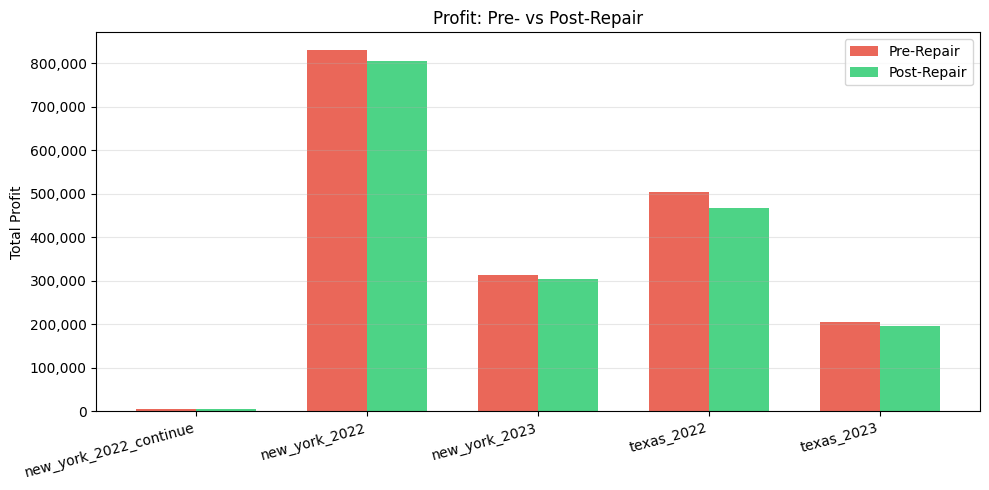

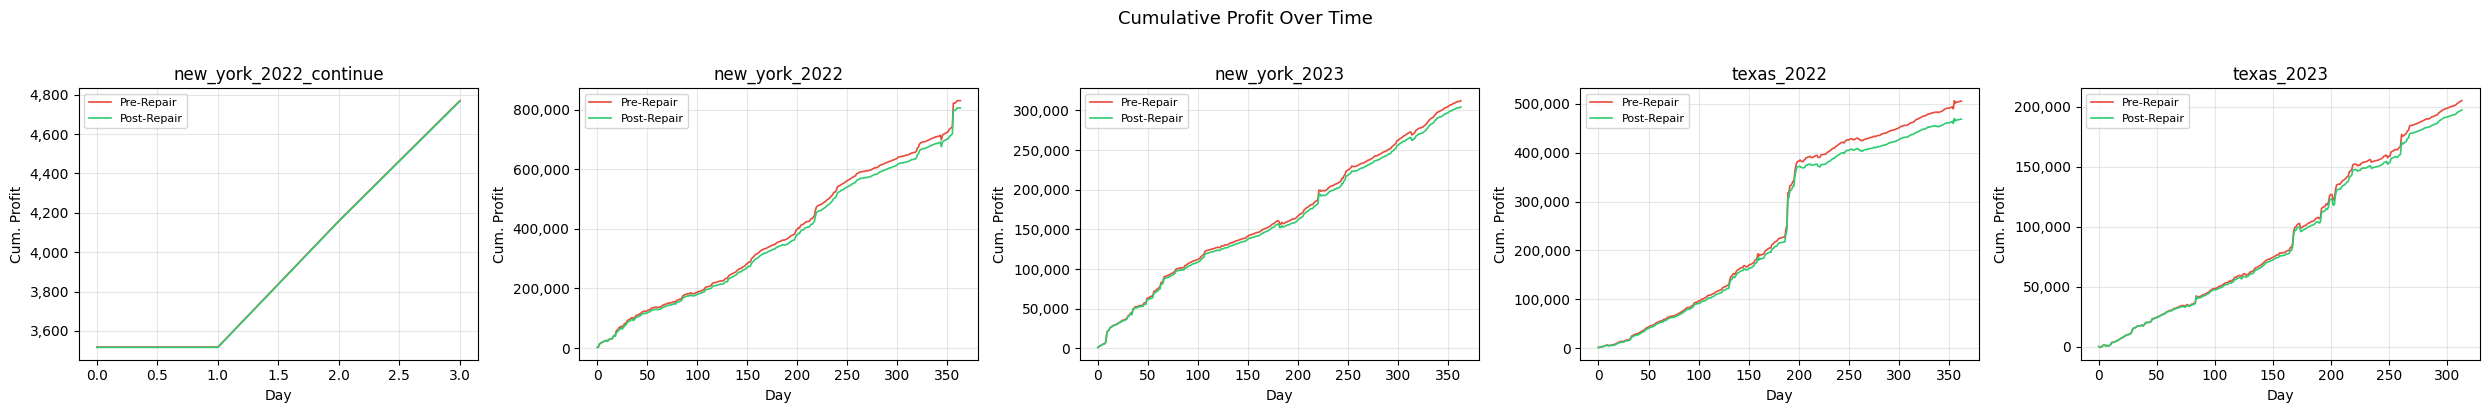


TABLE 2: Repair-Only Baseline (Zero → Repair)
               Dataset  Days  Zero→Repair  GPT (raw)  GPT+Repair Zero/GPT+Repair
new_york_2022_continue     4          0.0    4769.30     4766.44            0.0%
         new_york_2022   364          0.0  830022.95   805492.47            0.0%
         new_york_2023   364          0.0  312220.06   304382.64            0.0%
            texas_2022   363          0.0  505160.24   468406.58            0.0%
            texas_2023   314          0.0  204928.07   197121.33            0.0%


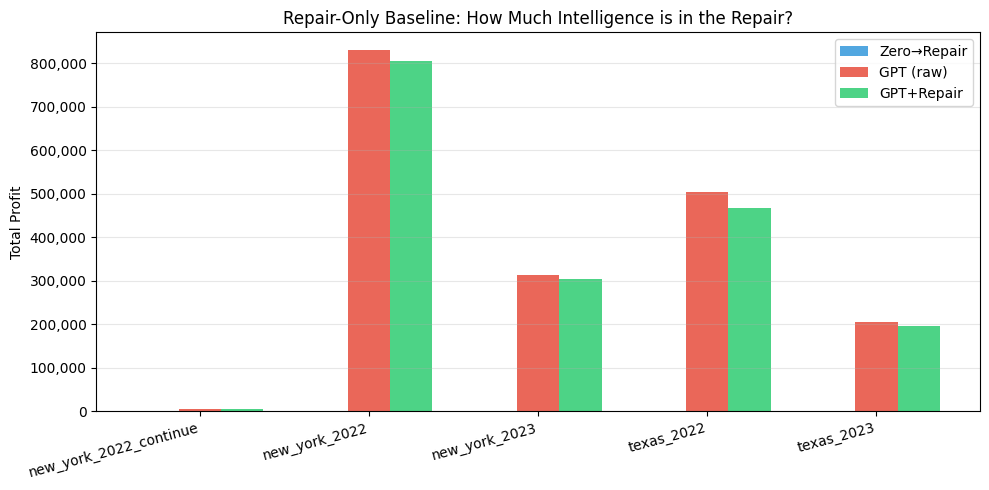


TABLE 3: Per-Constraint Repair Decomposition
Dataset                new_york_2022  new_york_2022_continue  new_york_2023  texas_2022  texas_2023
Repair                                                                                             
C1+C7+C12 (SOC clamp)      829291.37                 4766.46      312145.81   504832.79   205294.11
C4 (charge clip)           831661.24                 4766.46      313533.98   509227.25   206866.02
C4+C5 (power clip)         805144.58                 4766.46      304382.98   467393.61   197121.76
C5 (discharge clip)        801278.56                 4766.46      300845.60   458685.23   195864.34
C6 (no simult c/d)         829291.37                 4766.46      312145.81   504832.79   205294.11
Corrected CSV              805492.47                 4766.44      304382.64   468406.58   197121.33
Full repair                805144.58                 4766.46      304382.98   467393.61   197121.76
None (original)            830022.95                 4

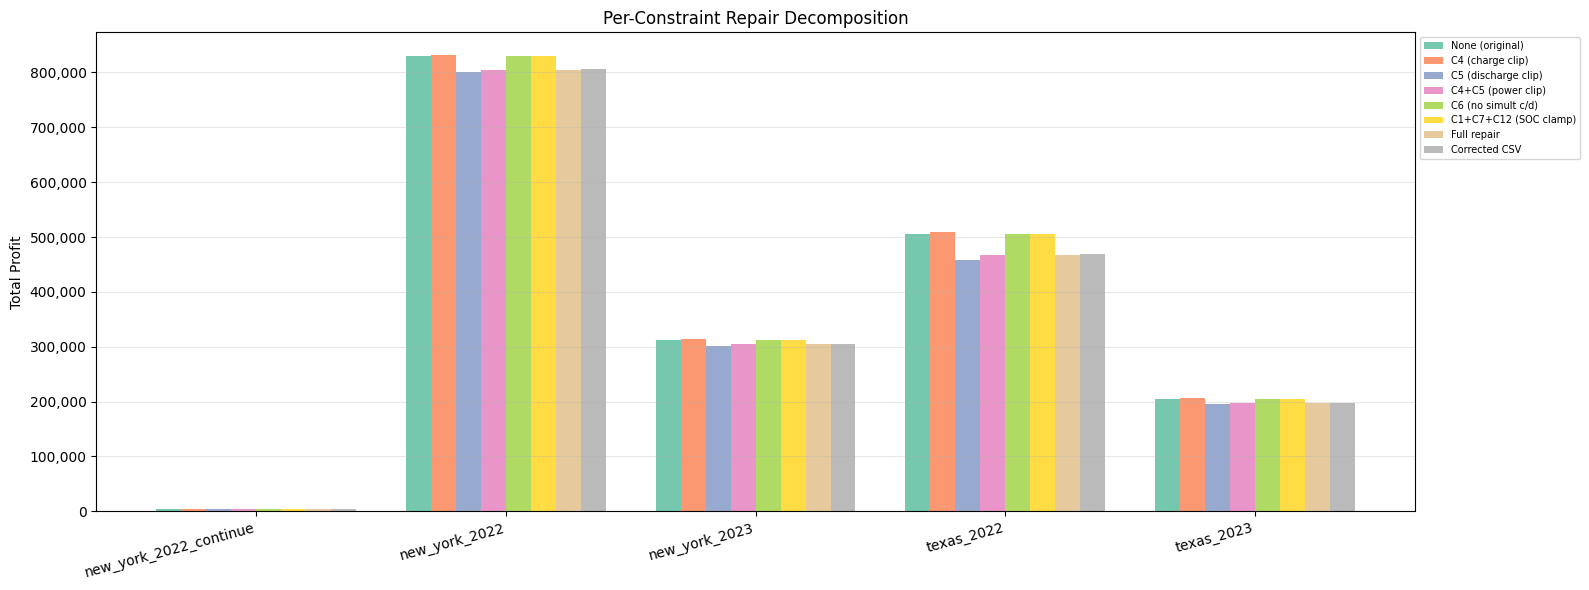

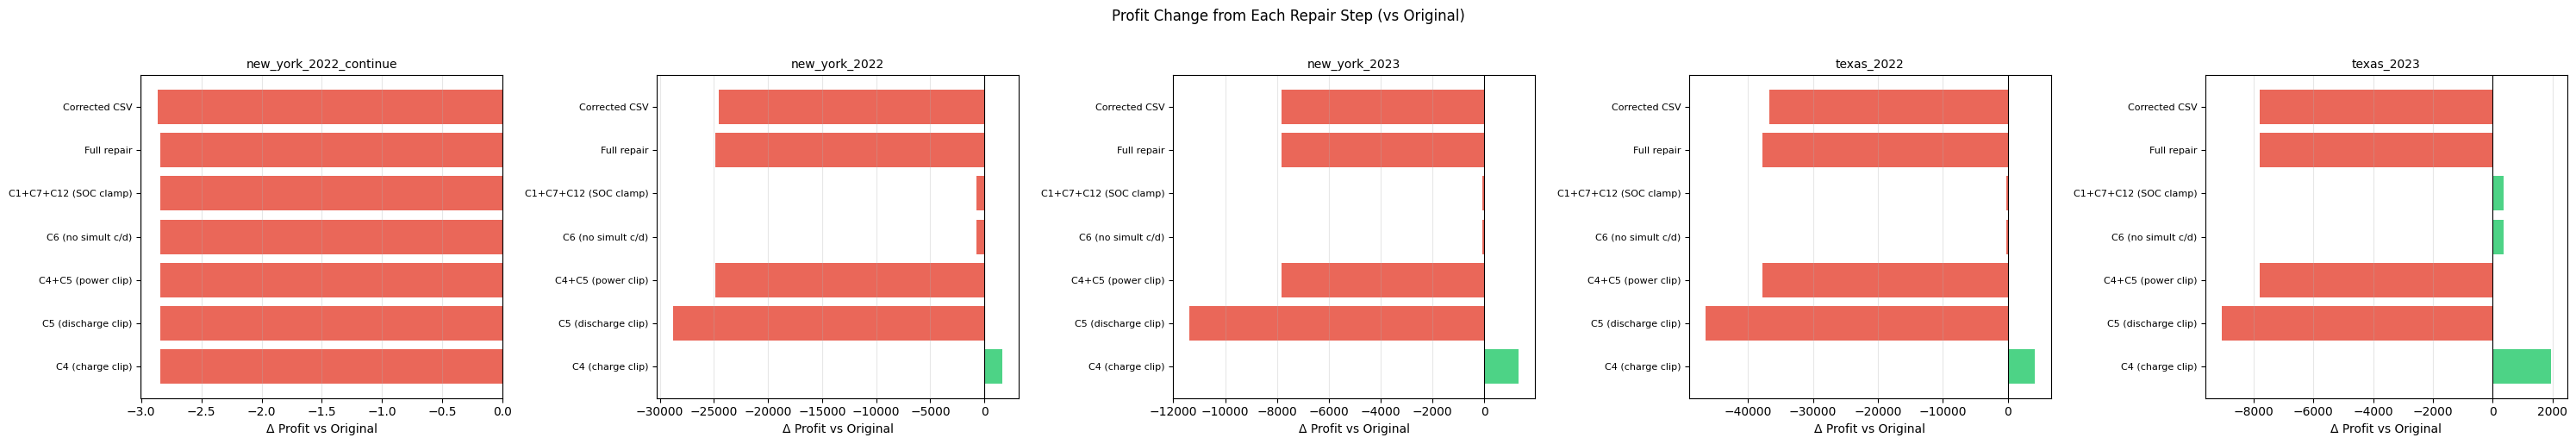


All plots saved to: /content/drive/MyDrive/energy_finetuning_35/new_outputs/plots


In [ ]:
# -*- coding: utf-8 -*-
"""
Repair Profit Analysis
  (1) Profit pre- vs post-repair table + plot
  (2) Repair-only baseline (zero → repair)
  (3) Per-constraint repair decomposition: apply only C4, C5, etc. individually
"""

import os, csv, math, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dataclasses import dataclass
from typing import List, Tuple, Dict

# ============================================================================
# Config
# ============================================================================
BASE_DIR = "/content/drive/MyDrive/energy_finetuning_35/new_outputs"
PLOT_DIR = os.path.join(BASE_DIR, "plots")

# ============================================================================
# Battery + helpers
# ============================================================================
@dataclass
class BatteryConfig:
    capacity_kwh: float = 49.44
    cmax_kw: float = 12.36
    dmax_kw: float = 12.36
    eta_c: float = 0.95
    eta_d: float = 0.95
    soc_min: float = 0.0
    soc_max: float = 1.0
    soc_target: float = 0.0
    dt: float = 1.0
    allow_export: bool = True


def sf(val, default=0.0):
    try:
        v = float(val)
        return default if (math.isnan(v) or math.isinf(v)) else v
    except (ValueError, TypeError):
        return default


def read_csv_days(path):
    with open(path) as f:
        rows = list(csv.DictReader(f))
    return [rows[i:i+24] for i in range(0, len(rows), 24) if len(rows[i:i+24]) == 24]


def auto_discover_pairs(base_dir):
    all_csvs = {os.path.basename(f) for f in glob.glob(os.path.join(base_dir, "*.csv"))}
    pairs, seen = [], set()
    for fname in sorted(all_csvs):
        if "_corrected" in fname:
            base = fname.split("_corrected")[0] + ".csv"
            if base in all_csvs and base not in seen:
                pairs.append((base, fname))
                seen.add(base)
    return pairs


def make_label(fname):
    return fname.replace("gpt4_hourly_arbitrage_", "").replace(".csv", "")


# ============================================================================
# Core simulation
# ============================================================================
def forward_simulate_and_clamp(c, d, batt, soc0):
    T, C = 24, batt.capacity_kwh
    c, d = list(c), list(d)
    soc = [soc0]
    for t in range(T):
        delta = (batt.eta_c * c[t] * batt.dt - d[t] * batt.dt / batt.eta_d) / C
        nxt = soc[t] + delta
        if nxt > batt.soc_max:
            needed = (batt.soc_max - soc[t]) * C + d[t] * batt.dt / batt.eta_d
            c[t] = max(0.0, needed / (batt.eta_c * batt.dt))
            nxt = batt.soc_max
        elif nxt < batt.soc_min:
            available = (soc[t] - batt.soc_min) * C + batt.eta_c * c[t] * batt.dt
            d[t] = max(0.0, available * batt.eta_d / batt.dt)
            nxt = batt.soc_min
        soc.append(nxt)
    return c, d, soc


def minimal_correct(c_orig, d_orig, batt, soc0, forecast_prices, max_iter=3):
    T, C = 24, batt.capacity_kwh
    c = [max(0.0, min(float(x), batt.cmax_kw)) for x in c_orig]
    d = [max(0.0, min(float(x), batt.dmax_kw)) for x in d_orig]
    for t in range(T):
        if c[t] > 1e-6 and d[t] > 1e-6:
            ce = c[t] * batt.eta_c * batt.dt
            de = d[t] * batt.dt / batt.eta_d
            if ce >= de:
                c[t], d[t] = (ce - de) / (batt.eta_c * batt.dt), 0.0
            else:
                c[t], d[t] = 0.0, (de - ce) * batt.eta_d / batt.dt
    for _ in range(max_iter):
        c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
        if soc[T] >= batt.soc_target - 1e-6:
            break
        deficit = (batt.soc_target - soc[T]) * C
        for t in sorted(range(T), key=lambda t: forecast_prices[t]):
            if deficit <= 1e-6:
                break
            hp = batt.cmax_kw - c[t]
            hs = (batt.soc_max - soc[t]) * C / (batt.eta_c * batt.dt) if soc[t] < batt.soc_max else 0.0
            add_p = max(0.0, min(hp, hs))
            if add_p > 1e-6:
                e = min(add_p * batt.eta_c * batt.dt, deficit)
                c[t] += e / (batt.eta_c * batt.dt)
                deficit -= e
            if deficit > 1e-6 and d[t] > 1e-6:
                e = min(d[t] * batt.dt / batt.eta_d, deficit)
                d[t] = max(0.0, d[t] - e * batt.eta_d / batt.dt)
                deficit -= e
    c, d, soc = forward_simulate_and_clamp(c, d, batt, soc0)
    return c, d, soc


def compute_profit_from_cd(c, d, soc, actual_prices, actual_demand, batt):
    total, dt = 0.0, batt.dt
    for t in range(24):
        net = actual_demand[t] + c[t] - d[t]
        imp_t = max(net, 0.0)
        exp_t = max(-net, 0.0) if batt.allow_export else 0.0
        baseline = actual_prices[t] * actual_demand[t] * dt
        actual_cost = actual_prices[t] * imp_t * dt - actual_prices[t] * exp_t * dt
        total += baseline - actual_cost
    return total


# ============================================================================
# Per-constraint partial repairs
# Each applies ONLY that fix + SOC recompute from c,d → profit
# ============================================================================

def apply_C4_only(c, d, batt, soc0, _fp):
    """C4: Clip charge to [0, cmax]."""
    c_f = [max(0.0, min(float(x), batt.cmax_kw)) for x in c]
    d_f = [float(x) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C5_only(c, d, batt, soc0, _fp):
    """C5: Clip discharge to [0, dmax]."""
    c_f = [float(x) for x in c]
    d_f = [max(0.0, min(float(x), batt.dmax_kw)) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C4C5(c, d, batt, soc0, _fp):
    """C4+C5: Clip both power limits."""
    c_f = [max(0.0, min(float(x), batt.cmax_kw)) for x in c]
    d_f = [max(0.0, min(float(x), batt.dmax_kw)) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C6_only(c, d, batt, soc0, _fp):
    """C6: Net out simultaneous charge/discharge."""
    c_f, d_f = [float(x) for x in c], [float(x) for x in d]
    for t in range(24):
        if c_f[t] > 1e-6 and d_f[t] > 1e-6:
            ce = c_f[t] * batt.eta_c * batt.dt
            de = d_f[t] * batt.dt / batt.eta_d
            if ce >= de:
                c_f[t], d_f[t] = (ce - de) / (batt.eta_c * batt.dt), 0.0
            else:
                c_f[t], d_f[t] = 0.0, (de - ce) * batt.eta_d / batt.dt
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_C1C7C12(c, d, batt, soc0, _fp):
    """C1/C7/C12: SOC bounds + dynamics (forward sim + clamp, no power clip)."""
    c_f = [float(x) for x in c]
    d_f = [float(x) for x in d]
    return forward_simulate_and_clamp(c_f, d_f, batt, soc0)


def apply_full(c, d, batt, soc0, fp):
    """Full repair pipeline."""
    return minimal_correct(c, d, batt, soc0, fp)


PARTIAL_REPAIRS = {
    "C4 (charge clip)":        apply_C4_only,
    "C5 (discharge clip)":     apply_C5_only,
    "C4+C5 (power clip)":      apply_C4C5,
    "C6 (no simult c/d)":      apply_C6_only,
    "C1+C7+C12 (SOC clamp)":   apply_C1C7C12,
    "Full repair":             apply_full,
}


# ============================================================================
# Analysis
# ============================================================================

def profit_comparison_table(base_dir, pairs):
    records = []
    for orig_name, corr_name in pairs:
        op = os.path.join(base_dir, orig_name)
        cp = os.path.join(base_dir, corr_name)
        if not os.path.exists(op) or not os.path.exists(cp):
            continue
        df_o, df_c = pd.read_csv(op), pd.read_csv(cp)
        o_p, c_p = df_o['profit_step'].sum(), df_c['profit_step'].sum()
        records.append({
            "Dataset": make_label(orig_name), "Days": len(df_o)//24,
            "Pre-Repair": round(o_p, 2), "Post-Repair": round(c_p, 2),
            "Δ Profit": round(c_p - o_p, 2),
            "Δ %": round((c_p - o_p) / abs(o_p) * 100, 2) if o_p != 0 else 0,
        })
    return pd.DataFrame(records)


def cumulative_daily_profit(base_dir, pairs):
    result = {}
    for orig_name, corr_name in pairs:
        op = os.path.join(base_dir, orig_name)
        cp = os.path.join(base_dir, corr_name)
        if not os.path.exists(op) or not os.path.exists(cp):
            continue
        days_o, days_c = read_csv_days(op), read_csv_days(cp)
        n = min(len(days_o), len(days_c))
        daily_o = [sum(sf(r['profit_step']) for r in d) for d in days_o[:n]]
        daily_c = [sum(sf(r['profit_step']) for r in d) for d in days_c[:n]]
        result[make_label(orig_name)] = (np.cumsum(daily_o), np.cumsum(daily_c))
    return result


def repair_only_baseline(base_dir, pairs):
    records = []
    batt, soc0 = BatteryConfig(), 0.5
    for orig_name, corr_name in pairs:
        op = os.path.join(base_dir, orig_name)
        cp = os.path.join(base_dir, corr_name)
        if not os.path.exists(op) or not os.path.exists(cp):
            continue
        days = read_csv_days(op)
        label = make_label(orig_name)
        zero_total, gpt_total = 0.0, 0.0
        for day_rows in days:
            pa = [sf(r['prices_actual']) for r in day_rows]
            pf = [sf(r['prices_forecast']) for r in day_rows]
            ad = [sf(r['actual_demand']) for r in day_rows]
            gpt_total += sum(sf(r['profit_step']) for r in day_rows)
            c_r, d_r, s_r = minimal_correct([0.0]*24, [0.0]*24, batt, soc0, pf)
            zero_total += compute_profit_from_cd(c_r, d_r, s_r, pa, ad, batt)
        rep_total = pd.read_csv(cp)['profit_step'].sum()
        records.append({
            "Dataset": label, "Days": len(days),
            "Zero→Repair": round(zero_total, 2),
            "GPT (raw)": round(gpt_total, 2),
            "GPT+Repair": round(rep_total, 2),
            "Zero/GPT+Repair": f"{zero_total/rep_total*100:.1f}%" if rep_total else "N/A",
        })
    return pd.DataFrame(records)


def per_constraint_decomposition(base_dir, pairs):
    """Apply each partial repair individually → measure total profit."""
    batt, soc0 = BatteryConfig(), 0.5
    records = []
    for orig_name, corr_name in pairs:
        op = os.path.join(base_dir, orig_name)
        cp = os.path.join(base_dir, corr_name)
        if not os.path.exists(op) or not os.path.exists(cp):
            continue
        days = read_csv_days(op)
        label = make_label(orig_name)
        pre_total = sum(sum(sf(r['profit_step']) for r in d) for d in days)
        post_total = pd.read_csv(cp)['profit_step'].sum()

        records.append({"Dataset": label, "Repair": "None (original)",
                        "Profit": round(pre_total, 2)})
        for rname, rfn in PARTIAL_REPAIRS.items():
            total = 0.0
            for day_rows in days:
                pa = [sf(r['prices_actual']) for r in day_rows]
                pf = [sf(r['prices_forecast']) for r in day_rows]
                ad = [sf(r['actual_demand']) for r in day_rows]
                c_o = [sf(r['charge_MW']) for r in day_rows]
                d_o = [sf(r['discharge_MW']) for r in day_rows]
                c_f, d_f, s_f = rfn(c_o, d_o, batt, soc0, pf)
                total += compute_profit_from_cd(c_f, d_f, s_f, pa, ad, batt)
            records.append({"Dataset": label, "Repair": rname,
                            "Profit": round(total, 2)})
        records.append({"Dataset": label, "Repair": "Corrected CSV",
                        "Profit": round(post_total, 2)})
    return pd.DataFrame(records)


# ============================================================================
# Plots
# ============================================================================

def plot_pre_post_bar(df1, save_dir):
    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(df1)), 0.35
    ax.bar(x - w/2, df1['Pre-Repair'],  w, label='Pre-Repair',  color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, df1['Post-Repair'], w, label='Post-Repair', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df1['Dataset'], rotation=15, ha='right')
    ax.set_ylabel('Total Profit'); ax.set_title('Profit: Pre- vs Post-Repair')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    fig.tight_layout(); fig.savefig(os.path.join(save_dir, "pre_post_profit.png"), dpi=150)
    plt.show()


def plot_cumulative(cum_data, save_dir):
    n = len(cum_data)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for i, (lbl, (co, cc)) in enumerate(cum_data.items()):
        ax = axes[0, i]
        ax.plot(co, label='Pre-Repair',  color='#e74c3c', lw=1.2)
        ax.plot(cc, label='Post-Repair', color='#2ecc71', lw=1.2)
        ax.set_title(lbl); ax.set_xlabel('Day'); ax.set_ylabel('Cum. Profit')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    fig.suptitle('Cumulative Profit Over Time', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "cumulative_profit.png"), dpi=150, bbox_inches='tight')
    plt.show()


def plot_repair_baseline(df2, save_dir):
    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(df2)), 0.25
    ax.bar(x - w, df2['Zero→Repair'], w, label='Zero→Repair', color='#3498db', alpha=0.85)
    ax.bar(x,     df2['GPT (raw)'],   w, label='GPT (raw)',   color='#e74c3c', alpha=0.85)
    ax.bar(x + w, df2['GPT+Repair'],  w, label='GPT+Repair',  color='#2ecc71', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df2['Dataset'], rotation=15, ha='right')
    ax.set_ylabel('Total Profit')
    ax.set_title('Repair-Only Baseline: How Much Intelligence is in the Repair?')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "repair_baseline.png"), dpi=150)
    plt.show()


def plot_per_constraint(df3, save_dir):
    datasets = df3['Dataset'].unique()
    repairs = df3['Repair'].unique()
    n_r = len(repairs)
    colors = plt.cm.Set2(np.linspace(0, 1, n_r))
    fig, ax = plt.subplots(figsize=(max(12, 2*n_r), 6))
    x, tw = np.arange(len(datasets)), 0.8
    w = tw / n_r
    for j, rep in enumerate(repairs):
        vals = [df3[(df3['Dataset']==ds)&(df3['Repair']==rep)]['Profit'].values[0]
                if len(df3[(df3['Dataset']==ds)&(df3['Repair']==rep)]) else 0
                for ds in datasets]
        ax.bar(x - tw/2 + w/2 + j*w, vals, w, label=rep, color=colors[j], alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(datasets, rotation=15, ha='right')
    ax.set_ylabel('Total Profit'); ax.set_title('Per-Constraint Repair Decomposition')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "per_constraint.png"), dpi=150, bbox_inches='tight')
    plt.show()


def plot_constraint_delta(df3, save_dir):
    """Δ profit from each repair vs original — horizontal bars per dataset."""
    datasets = df3['Dataset'].unique()
    repairs = [r for r in df3['Repair'].unique() if r != 'None (original)']
    fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 5), squeeze=False)
    for i, ds in enumerate(datasets):
        ax = axes[0, i]
        sub = df3[df3['Dataset'] == ds]
        base = sub[sub['Repair'] == 'None (original)']['Profit'].values[0]
        deltas, labels = [], []
        for rep in repairs:
            row = sub[sub['Repair'] == rep]
            if len(row):
                deltas.append(row['Profit'].values[0] - base)
                labels.append(rep)
        colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
        ax.barh(range(len(labels)), deltas, color=colors, alpha=0.85)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('Δ Profit vs Original'); ax.set_title(ds, fontsize=10)
        ax.axvline(0, color='black', lw=0.8); ax.grid(axis='x', alpha=0.3)
    fig.suptitle('Profit Change from Each Repair Step (vs Original)', fontsize=12, y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "constraint_delta.png"), dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
# Main
# ============================================================================
def main():
    os.makedirs(PLOT_DIR, exist_ok=True)
    pairs = auto_discover_pairs(BASE_DIR)
    if not pairs:
        print("No auto-discovered pairs found. Check BASE_DIR path.")
        return
    print(f"Found {len(pairs)} pairs:")
    for o, c in pairs:
        print(f"  {o}  →  {c}")

    # --- Table 1 ---
    print("\n" + "="*70 + "\nTABLE 1: Profit Pre- vs Post-Repair\n" + "="*70)
    df1 = profit_comparison_table(BASE_DIR, pairs)
    print(df1.to_string(index=False))
    plot_pre_post_bar(df1, PLOT_DIR)
    cum = cumulative_daily_profit(BASE_DIR, pairs)
    plot_cumulative(cum, PLOT_DIR)

    # --- Table 2 ---
    print("\n" + "="*70 + "\nTABLE 2: Repair-Only Baseline (Zero → Repair)\n" + "="*70)
    df2 = repair_only_baseline(BASE_DIR, pairs)
    print(df2.to_string(index=False))
    plot_repair_baseline(df2, PLOT_DIR)

    # --- Table 3 ---
    print("\n" + "="*70 + "\nTABLE 3: Per-Constraint Repair Decomposition\n" + "="*70)
    df3 = per_constraint_decomposition(BASE_DIR, pairs)
    pivot = df3.pivot(index='Repair', columns='Dataset', values='Profit')
    print(pivot.to_string())
    plot_per_constraint(df3, PLOT_DIR)
    plot_constraint_delta(df3, PLOT_DIR)

    print(f"\nAll plots saved to: {PLOT_DIR}")


if __name__ == "__main__":
    main()